# Goal - Create a Line of Best Fit (regression)

In Module 2, we looked at how to calculate various sum of squares related to variance to get an F-statistic, which we could use for hypothesis testing. We will again use "sum of squares" to create a line of best fit for a set of data points. 

Let's consider a simple case where we want to predict a response ($y$) with a single predictor variable ($x$). A linear regression is a linear function that takes our predictor variable and gives a predicted response outcome: $Y = \beta_1 x + \beta_0$. The question is then "How do we choose $\beta_1$ and $\beta_0$ to have the **best** prediction line?" This is where sum of squares comes in!

The *Residual Sum of Squares (RSS)* is the sum of the residuals squared. A residual is the difference between our predicted response $Y_i$ and the actual response $y_i$. So we can write 

$$ \text{RSS } = \sum_{i=1}^n (y_i - Y_i)^2 $$

Let's substitute our equation for $Y$ in:

$$ \text{RSS } = \sum_{i=1}^n (y_i - \beta_1 x_i - \beta_0)^2 $$

Since we want to *minimize* RSS, we can take the derivative, set it equal to 0, and solve. We aren't in Calc 1 anymore so we don't need to actually do that calculation by hand. If we did we would get:

$$ \hat{\beta_1} = \frac{ \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n(x_i-\bar{x})^2} $$

$$ \hat{\beta_0} = \bar{y} - \hat{\beta_1} \bar{x} $$

where $\bar{x}$ is the average x-value and $\bar{y}$ is the average y-value. 

$\hat{\beta_1}$ and $\hat{\beta_0}$ are our best estimates at the "true" regression line $Y = \beta_1 x + \beta_0$. This method of minimizing RSS is called the *Ordinary Least Squares* method.

Below is some random data plotted (blue points) along with its regression line (black oblique line) and the residuals (red vertical lines). 

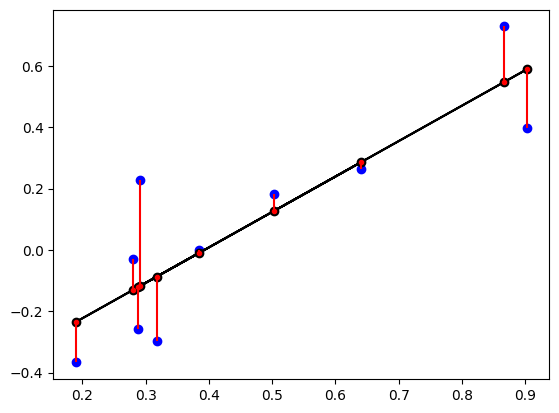

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Random data
X_random = np.random.rand(10,1)
y_random = X_random + np.random.rand(10,1)*(-1)**np.random.randint(0,2)

# Creating the linear regression is just two steps in Python!
reg_lin = LinearRegression()
reg_lin.fit(X_random, y_random)

# We can then plug in the random x-values to get the associated predicted y-values
y_predictions = reg_lin.predict(X_random)

# Our residual array is the set of actual y-values - predicted y-values
y_error_array = y_random - y_predictions

y_error_lower = []
y_error_upper = []
y_error_list = [y_err[0] for y_err in y_error_array]

for index in range(0, len(y_error_array)):
    temp_y_error = y_error_list[index]  
    if y_error_list[index] > 0:
        y_error_lower.append(temp_y_error)
        y_error_upper.append(0)
    else:
        y_error_upper.append(abs(temp_y_error))
        y_error_lower.append(0)

plt.plot(X_random, y_random, 'bo')
plt.plot(X_random, y_predictions, 'ko-')
plt.errorbar(X_random.reshape(10,), y_predictions.reshape(10,), yerr=[y_error_upper, y_error_lower], fmt='.r')
plt.show()